# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

df_sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')
df_sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [2]:
# Группируем по user_id и считаем количество уникальных session_id
df_history_group = df_sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
df_history_group.columns = ['user_id', 'unique_sessions']
# Находим пользователя с наибольшим количеством уникальных сессий и берем его user_id
top_user = df_history_group.loc[df_history_group['unique_sessions'].idxmax(), 'user_id']
df_top_user = df_sessions_history[df_sessions_history['user_id'] == top_user]
display(df_top_user)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования.

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [3]:
# Число уникальных пользователей по дням
df_history_group_all = df_sessions_history.groupby('session_date')['user_id'].nunique().reset_index()

# Число зарегистрированных пользователей по дням
df_filtered = df_sessions_history[(df_sessions_history.registration_flag==1)]
df_history_group_reg = df_filtered.groupby('session_date')['user_id'].nunique().reset_index()

In [4]:
# Группируем датасеты 
df_merged = df_history_group_all.merge(df_history_group_reg, on='session_date', how='left')

# Исправляем названия колонок после merge
df_merged.rename(columns={'user_id_x': 'unique_users', 'user_id_y': 'registered_users'}, inplace=True)

# Считаем долю зарегистрированных 
df_merged['reg_ratio'] = df_merged['registered_users'] / df_merged['unique_users'] 
df_merged['reg_ratio'] = df_merged['reg_ratio'].fillna(0)

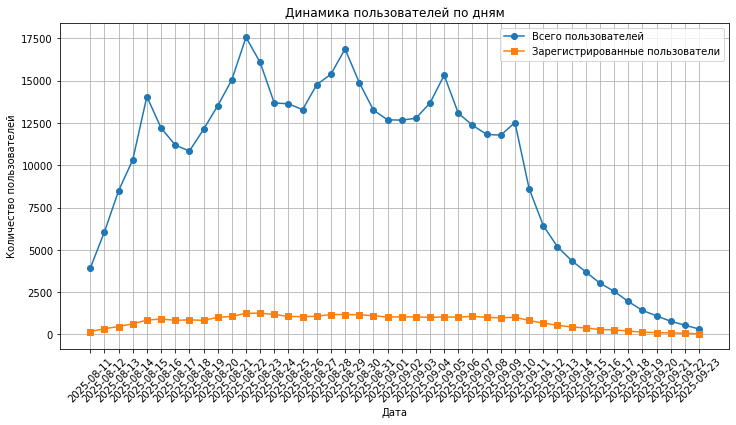

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

plt.plot(df_merged['session_date'], df_merged['unique_users'], label='Всего пользователей', marker='o')
plt.plot(df_merged['session_date'], df_merged['registered_users'], label='Зарегистрированные пользователи', marker='s')

plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.title('Динамика пользователей по дням')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

**Промежуточный вывод**

_Общий тренд_
- Количество пользователей в системе сначала возрастает, достигая пика, а затем постепенно снижается.
- После максимума наблюдается постепенное падение активности, что может быть связано с окончанием маркетинговой кампании, снижением интереса или сезонными колебаниями.

_Разница между общими и зарегистрированными пользователями_
- Видно, что общее количество пользователей (синяя линия) значительно превышает количество зарегистрированных пользователей (оранжевая линия).
- Доля зарегистрированных пользователей остаётся относительно стабильной, но при этом имеет небольшие колебания.
- Низкая доля зарегистрированных пользователей может говорить о недостаточно эффективном процессе регистрации или отсутствии стимулов для регистрации.

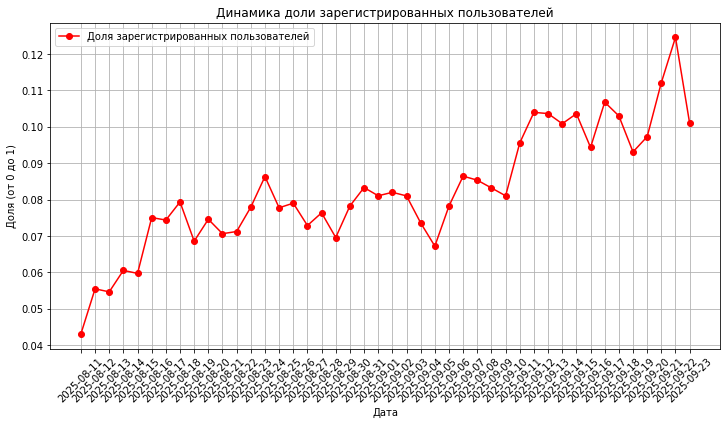

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(df_merged['session_date'], df_merged['reg_ratio'], label='Доля зарегистрированных пользователей', marker='o', color='red')

plt.xlabel('Дата')
plt.ylabel('Доля (от 0 до 1)')
plt.title('Динамика доли зарегистрированных пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

**Промежуточный вывод**

_Общий тренд_
- Доля зарегистрированных пользователей постепенно увеличивается в течение всего периода.
- В начале графика наблюдается резкий рост, затем идут значительные колебания, но общий тренд остаётся восходящим.

_Колебания значений_
- После начального роста доля зарегистрированных пользователей стабилизируется в пределах 0.07–0.09.
- В конце периода наблюдается новый скачок до 0.12, но затем происходит небольшое снижение.

_Возможные объяснения_
- Рост доли может быть связан с улучшением процесса регистрации, изменением воронки привлечения или ростом интереса к сервису.
- Колебания могут быть вызваны изменением в трафике – например, если в определённые дни приходило больше новых пользователей, но конверсия в регистрацию оставалась разной.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы на то, что он зарегистрируется и оплатит подписку.

- Найдите количество сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29160 сессиях, две страницы в 105536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

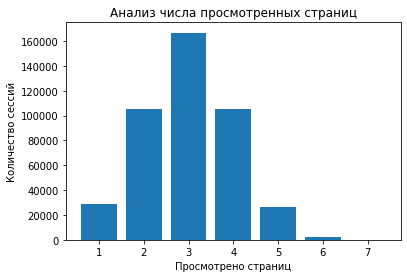

In [7]:
# Группируем и считаем количество сессий на количество просмотренных страниц
df_grp_page = df_sessions_history.groupby('page_counter')['session_id'].nunique().reset_index()
df_grp_page.rename(columns={'session_id': 'unique_sessions'}, inplace=True)

plt.bar(df_grp_page['page_counter'], df_grp_page['unique_sessions'])

plt.xlabel('Просмотрено страниц')
plt.ylabel('Количество сессий')
plt.title('Анализ числа просмотренных страниц')

plt.show()

**Промежуточный вывод**

- Анализ числа просмотренных страниц показывает нормальное распределение.
- Наибольшее количество сессий приходится на 3 просмотренные страницы, что говорит о хорошем уровне удержания пользователя и его заинтересованности.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий ко всем сессиям по дням за весь период наблюдения.

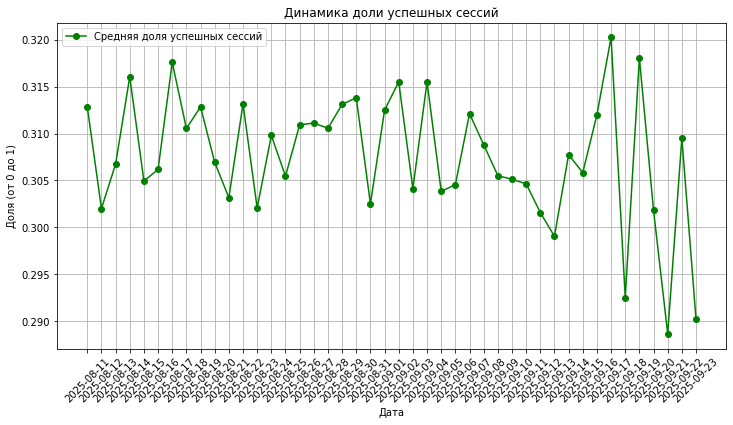

In [8]:
# Добавляем новый столбец good_session
df_sessions_history['good_session'] = df_sessions_history['page_counter'].apply(lambda x: 1 if x >= 4 else 0)
# Считаем среднюю долю good_session по дням
df_grp_session = df_sessions_history.groupby('session_date')['good_session'].mean().reset_index()

plt.figure(figsize=(12, 6))

plt.plot(df_grp_session['session_date'], df_grp_session['good_session'], label='Средняя доля успешных сессий', marker='o', color='green')

plt.xlabel('Дата')
plt.ylabel('Доля (от 0 до 1)')
plt.title('Динамика доли успешных сессий')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

**Промежуточный вывод**

- Средняя доля пользователей, просмотревших 4 и более страниц, держится в пределах 29%–32%.
- Наблюдаются колебания показателя, но в целом тренд остается стабильным.
- В середине периода фиксируются небольшие пики, но затем значение возвращается к средней отметке.
- В последние дни эксперимента наблюдаются резкие скачки вверх и вниз, что может быть связано с изменением активности пользователей или снижением общего количества сессий.
- В целом, динамика не свидетельствует о резких изменениях в пользовательском поведении, что может говорить о стабильности показателя.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика, рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вам уже приходилось рассчитывать размеры выборки, используя онлайн-калькуляторы. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего дизайна эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки мы будем использовать метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [9]:
from statsmodels.stats.power import NormalIndPower

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
mde = 0.03  # Минимальный детектируемый эффект

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = mde,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 17441


#### 2.1. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста, исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [10]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = df_sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users:.0f} пользователей в день составит {test_duration} дня")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 4 дня


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой можно было бы увидеть возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [11]:
# Загружаем датасет
df_sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')
df_sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [12]:
# Данные только за один день, поэтому будем использовать группировку по часам
df_sessions_test_part['session_hour'] = pd.to_datetime(df_sessions_test_part['session_start_ts']).dt.hour

# Группируем и считаем уникальных пользователей в каждой группе
df_group_test = df_sessions_test_part.groupby(['session_date', 'session_hour', 'test_group'])['user_id'].nunique().reset_index()

# Преобразуем таблицу
df_pivot = df_group_test.pivot(index=['session_date', 'session_hour'], columns='test_group', values='user_id')
df_pivot.columns = ['A', 'B']
df_pivot = df_pivot.reset_index()

# Считаем процентную разницу
df_pivot['diff_percent'] = 100 * abs(df_pivot['A'] - df_pivot['B']) / df_pivot['A']

df_pivot

,session_date,session_hour,A,B,diff_percent
0,2025-10-14,0,18,30,66.666667
1,2025-10-14,1,12,12,0.000000
2,2025-10-14,2,4,10,150.000000
3,2025-10-14,3,3,11,266.666667
4,2025-10-14,4,2,7,250.000000
5,2025-10-14,5,1,8,700.000000
6,2025-10-14,6,2,7,250.000000
7,2025-10-14,7,1,9,800.000000
8,2025-10-14,8,3,9,200.000000
9,2025-10-14,9,3,15,400.000000


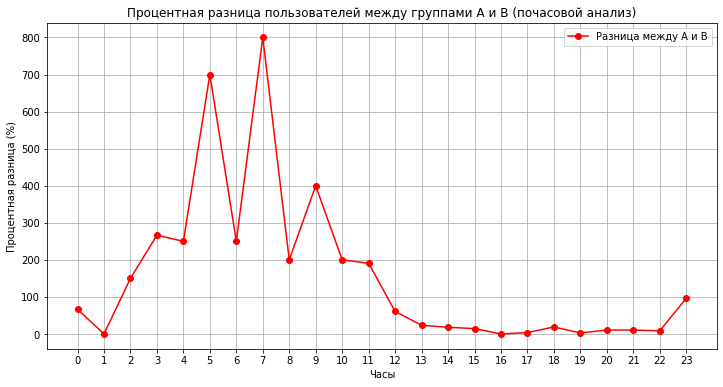

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(df_pivot['session_hour'], df_pivot['diff_percent'], marker='o', linestyle='-', color='red', label='Разница между A и B')

plt.xlabel('Часы')
plt.ylabel('Процентная разница (%)')
plt.title('Процентная разница пользователей между группами A и B (почасовой анализ)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)

plt.show()

Общее количество пользователей за день:
Группа A: 1500
Группа B: 1613


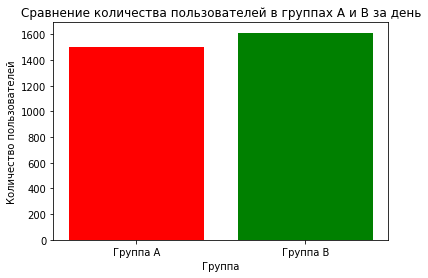

In [14]:
# Считаем общее количество пользователей в группах A и B за день
total_users_A = df_pivot['A'].sum()
total_users_B = df_pivot['B'].sum()

# Выводим текстовое сравнение
print(f"Общее количество пользователей за день:")
print(f"Группа A: {total_users_A}")
print(f"Группа B: {total_users_B}")

# Строим столбчатый график
plt.figure(figsize=(6, 4))
plt.bar(['Группа A', 'Группа B'], [total_users_A, total_users_B], color=['red', 'green'])
plt.xlabel("Группа")
plt.ylabel("Количество пользователей")
plt.title("Сравнение количества пользователей в группах A и B за день")
plt.show()

**Промежуточный вывод**

_Распределение пользователей по группам A и B (по часам)_
- Почасовой анализ показал, что в ночное время (с 3 до 10 утра) наблюдаются резкие скачки процентной разницы между группами
- Это может быть связано с низким объемом трафика в это время, что делает статистику менее надежной.
- После 11 часов разница между группами уменьшается и стабилизируется, что говорит о равномерном распределении пользователей в течение активного времени суток.

_Суммарное количество пользователей за день_
- Группа A: 1500 пользователей.
- Группа B: 1613 пользователей.
- Визуальный анализ на столбчатом графике показывает, что разница между группами небольшая, но группа B немного превышает группу A.

_Выводы_
- Распределение пользователей по группам A и B в целом сбалансировано, но с небольшим перевесом в сторону группы B.
- А/В тест проходит корректно, но стоит учитывать ночные колебания в данных, так как низкий трафик в эти часы может вносить шум в статистику.

In [29]:
# Ячейка ревьера:
(df_sessions_test_part
 .groupby(['session_date', 'test_group'])['user_id'].nunique()
 .reset_index()
)

,session_date,test_group,user_id
0,2025-10-14,A,1477
1,2025-10-14,B,1466


#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [15]:
# Группируем по user_id и test_group, и если test_group > 1 - значит пользователь попал в обе группы
df_user_groups = df_sessions_test_part.groupby('user_id')['test_group'].nunique().reset_index()
# Считаем, сколько пользователей попало в обе группы
cross_users = df_user_groups[df_user_groups['test_group'] > 1].shape[0]

if cross_users == 0:
    print("Пересечений нет, группы независимы.")
else:
    print(f"Есть пересечения, {cross_users} пользователей попали в обе группы.")

Пересечений нет, группы независимы.


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройства и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [16]:
# Группируем по test_group и device
df_device_dist = df_sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().reset_index()
df_device_dist

,test_group,device,user_id
0,A,Android,656
1,A,Mac,156
2,A,PC,369
3,A,iPhone,296
4,B,Android,668
5,B,Mac,148
6,B,PC,381
7,B,iPhone,269


In [17]:
# Считаем процентные доли на каждое устройство в каждой группе
df_device_dist['percentage'] = df_device_dist.groupby('test_group')['user_id'].transform(lambda x: x / x.sum() * 100)
df_device_dist

,test_group,device,user_id,percentage
0,A,Android,656,44.414353
1,A,Mac,156,10.561950
2,A,PC,369,24.983074
3,A,iPhone,296,20.040623
4,B,Android,668,45.566166
5,B,Mac,148,10.095498
6,B,PC,381,25.989086
7,B,iPhone,269,18.349250


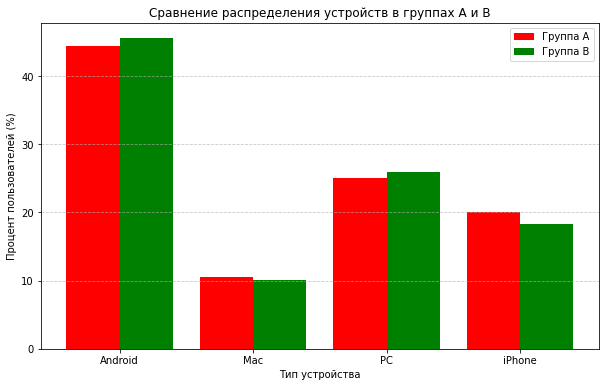

In [18]:
df_A = df_device_dist[df_device_dist['test_group'] == 'A']
df_B = df_device_dist[df_device_dist['test_group'] == 'B']

plt.figure(figsize=(10, 6))

# Получаем список устройств (они одинаковые для A и B)
devices = df_A['device'].values

# Задаём позиции для столбцов
x = np.arange(len(devices))
width = 0.4

# Рисуем столбцы для группы A
plt.bar(x - width/2, df_A['percentage'], width=width, color='red', label='Группа A')

# Рисуем столбцы для группы B
plt.bar(x + width/2, df_B['percentage'], width=width, color='green', label='Группа B')

# Настраиваем оси и подписи
plt.xlabel('Тип устройства')
plt.ylabel('Процент пользователей (%)')
plt.title('Сравнение распределения устройств в группах A и B')
plt.xticks(x, devices)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Промежуточный вывод**

- На графике представлены обе группы - так удобнее сравнивать распределение по девайсам между группами. 
- Как видно из графика - распределение практически одинаково между группами А и В.

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.


In [19]:
# Группируем по test_group и region
df_region = df_sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().reset_index()

# Считаем процентные доли на каждый регион в каждой группе
df_region['percentage'] = df_region.groupby('test_group')['user_id'].transform(lambda x: x / x.sum() * 100)
df_region

,test_group,region,user_id,percentage
0,A,CIS,644,43.601896
1,A,EU,224,15.165877
2,A,MENA,609,41.232227
3,B,CIS,645,43.997271
4,B,EU,217,14.802183
5,B,MENA,604,41.200546


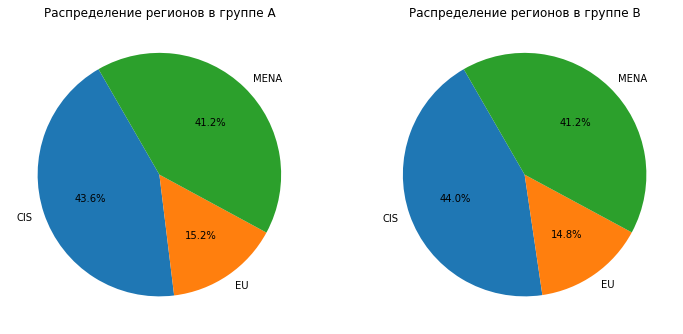

In [20]:
# Фильтруем по группам
df_A = df_region[df_region['test_group'] == 'A']
df_B = df_region[df_region['test_group'] == 'B']

plt.figure(figsize=(12, 6))  # Размер графиков

# Первый график – группа A
plt.subplot(1, 2, 1)  # 1 строка, 2 графика, первый график
plt.pie(df_A['percentage'], labels=df_A['region'], autopct='%1.1f%%', startangle=120)
plt.title('Распределение регионов в группе A')

# Второй график – группа B
plt.subplot(1, 2, 2)  # Второй график
plt.pie(df_B['percentage'], labels=df_B['region'], autopct='%1.1f%%', startangle=120)
plt.title('Распределение регионов в группе B')

plt.show()

**Промежуточный вывод**

- График распределения регионов в группах аналогично показывает максимально идентичные показатели.
- Оба графика показывают отличное распределение на две группы.

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Были ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение о том, корректно ли проходит A/B-тест или наблюдаются какие-либо нарушения.

**Вывод после проверки A/B-теста**

_Различие в количестве пользователей в двух группах_

Мы рассчитали количество уникальных пользователей в группах A и B по дням, а затем провели часовую разбивку.
Различие между группами A и B варьируется в течение дня, особенно в ночные и утренние часы, когда количество пользователей низкое.
Визуальный анализ на столбчатом графике показывает, что разница между группами небольшая, но группа B немного превышает группу A.

_Независимость выборок и пересечение пользователей_

Анализ показал, что пользователей, попавших одновременно в обе группы - нет. Следовательно, группы A и B независимы.

_Равномерность распределения по устройствам и регионам_

Мы проверили распределение пользователей по устройствам (Android, iPhone, Mac, PC) и регионам (CIS, EU, MENA).
Визуализация показала, что распределение устройств и регионов в группах A и B практически идентично, что свидетельствует о корректном разделении пользователей.

_Заключение_

На основе анализа можно сделать вывод, что A/B-тест проходит корректно:
- Пользователи распределены равномерно между группами, с небольшим перевесом в сторону группы B.
- Выборки независимы, пересечений нет.
- Распределение по устройствам и регионам совпадает в обеих группах.

Следовательно, текущая настройка эксперимента корректна, и можно переходить к анализу влияния изменения на ключевые метрики.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [21]:
df_sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')
df_sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [22]:
# Добавляем новый столбец good_session
df_sessions_test['good_session'] = df_sessions_test['page_counter'].apply(lambda x: 1 if x >= 4 else 0)

#### 4.2. Проверка корректности результатов теста

Прежде чем приступать к анализу ключевых продуктовых метрик, необходимо убедиться, что тест проведён корректно и вы будете сравнивать две сопоставимые группы.

- Рассчитайте количество уникальных сессий для каждого дня и обеих тестовых групп, используя группировку.

- Проверьте, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимы. Используйте статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

- В качестве ответа выведите на экран полученное значение p-value и интерпретируйте его.

In [23]:
from scipy.stats import ttest_ind

# Формулируем гипотезы
print("Нулевая гипотеза (H0): Среднее количество сессий в день не различается между группами A и B.")
print("Альтернативная гипотеза (H1): Среднее количество сессий в день в группе B выше, чем в группе A.")

# Группируем данные
df_sessions_group = df_sessions_test.groupby(['session_date', 'test_group'])['session_id'].nunique().reset_index()

# Разделяем на группы
group_a = df_sessions_group[df_sessions_group.test_group == 'A']['session_id']
group_b = df_sessions_group[df_sessions_group.test_group == 'B']['session_id']

# Выводим среднее количество сессий в день для каждой группы
mean_a = group_a.mean()
mean_b = group_b.mean()
print(f"Среднее количество сессий в день (группа A): {mean_a:.2f}")
print(f"Среднее количество сессий в день (группа B): {mean_b:.2f}")

# Уровень значимости
alpha = 0.05

# Запускаем t-тест
stat_ttest, p_value_ttest = ttest_ind(
    group_a,
    group_b,
    alternative='two-sided'  # Двусторонний тест
)

# Выводим p-value и интерпретируем результат
print(f"p-value теста Стьюдента = {p_value_ttest:.2f}")
if p_value_ttest > alpha:
    print("Нулевая гипотеза подтверждается. Различия между группами незначимы.")
else:
    print("Нулевая гипотеза отвергается. Различия статистически значимы.")

Нулевая гипотеза (H0): Среднее количество сессий в день не различается между группами A и B.
Альтернативная гипотеза (H1): Среднее количество сессий в день в группе B выше, чем в группе A.
Среднее количество сессий в день (группа A): 2477.55
Среднее количество сессий в день (группа B): 2522.70
p-value теста Стьюдента = 0.94
Нулевая гипотеза подтверждается. Различия между группами незначимы.


**Промежуточный вывод**

_Формулировка гипотез:_
- Нулевая гипотеза (H0): Среднее количество сессий в день в группах A и B не различается.
- Альтернативная гипотеза (H1): Среднее количество сессий в день в группе B выше, чем в группе A.

_Результаты анализа:_
- Среднее количество сессий в день:
- Группа A: примерное значение 2478 сессий
- Группа B: примерное значение 2523 сессии
- Статистический тест Стьюдента (t-test) дал p-value = 0.94.

_Интерпретация p-value:_
- Так как p-value значительно выше уровня значимости (α = 0.05), мы не отвергаем нулевую гипотезу.
- Это означает, что различия между группами A и B по количеству сессий в день не являются статистически значимыми.

_Вывод:_
- Группы A и B сбалансированы по количеству сессий в день, что говорит о корректности проведенного теста.

#### 4.3. Сравнение доли успешных сессий

Когда вы убедились, что количество сессий в обеих выборках не различалось, можно переходить к анализу ключевой метрики — доли успешных сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [24]:
# Группируем данные и считаем долю успешных сессий
df_sessions_group = df_sessions_test.groupby('test_group')['good_session'].mean().reset_index()

# Считаем абсолютную разницу
diff_absolute = (df_sessions_group.loc[df_sessions_group['test_group'] == 'B', 'good_session'].values[0] - 
                df_sessions_group.loc[df_sessions_group['test_group'] == 'A', 'good_session'].values[0])

# Считаем относительную разницу в процентах
diff_relative = (diff_absolute / df_sessions_group.loc[df_sessions_group['test_group'] == 'A', 'good_session'].values[0]) * 100

print(df_sessions_group)
print(f"Абсолютная разница между группами: {diff_absolute:.4f}")
print(f"Относительная разница между группами: {diff_relative:.2f}%")

  test_group  good_session
0          A      0.307723
1          B      0.318290
Абсолютная разница между группами: 0.0106
Относительная разница между группами: 3.43%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 0.5% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [25]:
from statsmodels.stats.proportion import proportions_ztest

# Формулируем статистические гипотезы
# H0: Доля успешных сессий в группах A и B равны
# H1: Доля успешных сессий в группе B выше, чем в группе A

# Группируем данные
group_a = df_sessions_test[df_sessions_test['test_group'] == 'A']['good_session']
group_b = df_sessions_test[df_sessions_test['test_group'] == 'B']['good_session']

# Считаем число успешных сессий и количество всех сессий в каждой группе
successes = [group_b.sum(), group_a.sum()]
observations = [group_b.count(), group_a.count()]

# Проверяем, улучшилась ли метрика в группе B
stat_ztest, p_value_ztest = proportions_ztest(
    successes,
    observations,
    alternative='larger'  # Тест на увеличение метрики в группе B
)

alpha = 0.05

# Выводим результат
if p_value_ztest < alpha:
    print(f"p_value_ztest = {p_value_ztest:.4f}. Разница статистически значима: метрика в группе B выше.")
else:
    print(f"p_value_ztest = {p_value_ztest:.4f}. Разница не является статистически значимой.")

p_value_ztest = 0.0002. Разница статистически значима: метрика в группе B выше.


**Промежуточный вывод**

_Формулировка гипотез:_

Нулевая гипотеза (H0): Доля успешных сессий в группах A и B не различается.
Альтернативная гипотеза (H1): Доля успешных сессий в группе B выше, чем в группе A.

_Результаты анализа:_

p-value = 0.0002

_Интерпретация p-value:_

p-value значительно ниже уровня значимости (α = 0.05), поэтому мы отвергаем нулевую гипотезу.
Это означает, что разница между группами A и B является статистически значимой.

_Вывод:_

Новый алгоритм рекомендаций привел к увеличению доли успешных сессий.
Разница подтверждена статистически - можно рекомендовать внедрение нового алгоритма в приложение.

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять новоовведение в приложение.

**Характеристики проведённого эксперимента**
- Эксперимент проводился в течение 20 дней, и данные были собраны за весь период тестирования.
- В тесте участвовали две группы пользователей: контрольная A и тестовая B, каждая из которых включала достаточное количество сессий для статистически значимого анализа.

**Влияние нового алгоритма рекомендаций на ключевую метрику**
- Основной анализ показал, что доля успешных сессий (количество пользователей, просмотревших 4 и более страниц) в тестовой группе B была на 3.43% выше, чем в контрольной группе A.
- Абсолютная разница между группами составила 0.0106. Это означает, что новый алгоритм рекомендаций привёл к небольшому, но заметному увеличению доли успешных сессий.

**Оценка статистической значимости эффекта**
- Для проверки статистической значимости различий был проведён z-тест.
- Полученное p-value = 0.0002, что значительно меньше уровня значимости 0.05.
- Это означает, что различия между группами не являются случайными, а действительно вызваны тестируемым изменением.

**Вывод: стоит ли внедрять нововведение?**
- Так как тест показал значимый положительный эффект на долю успешных сессий, можно сделать вывод, что новый алгоритм рекомендаций улучшает пользовательский опыт.
- Разница между группами хоть и не большая, но всё же достаточная, чтобы рекомендовать внедрение нового алгоритма в приложение.

**Итог:**
- Новый алгоритм рекомендаций показал статистически значимое улучшение метрики успешных сессий. Внедрение нововведения в приложение оправдано.